# State-conditioned FHR coefficients on CartPole

**Branch `fhr/state-conditioned-c` · 2026-08-23 · seeds 44/66 · SB3 FHRDQN
(tuned recipe: lr 2.3e-3, batch 64, net [256, 256], 50k steps; greedy
10-episode evaluation every 5k steps; return is capped at 500 = solved)**

## Variants at a glance

| # | variant | λ | in one sentence |
|---|---|---|---|
| — | **baseline** | 0 | The tuned SB3 recipe unchanged: the TD loss is the entire objective. |
| 9 | **standard FHR** (global c) | 0.5 | One coefficient vector $c \in \mathbb{R}^2$, shared across all states and episodes, optimised by autodiff jointly with $Q$ in its own optimiser group; the penalty $\lambda\,\mathrm{Huber}\!\big(Q(s_t,a_t) - \sum_j c_j Q(s_{t-j},a_{t-j})\big)$ rides every TD batch. λ = 0.5 is this environment's best recorded value from the earlier sweeps. |
| 1, 3 | **shared c(s, a)** | 0.5 / 1 | $c$ is predicted per transition by a linear head on the Q-network's **penultimate features** (+ one-hot action); penalty gradients also flow into the shared trunk, shaping the representation like an auxiliary head. |
| 2, 4 | **separate c(s, a)** | 0.5 / 1 | $c$ is predicted by an **independent** 64-unit MLP on [observation, one-hot action]; the Q-network feels the penalty only through the Q-values themselves. |
| 5–8 | **ARX** twins | 0.5 / 1 | Same as 1–4 plus learned $d$-coefficients on the two preceding **rewards**, letting the recurrence absorb reward events instead of forcing $Q$ to smooth through them. |

All predictor heads start with zero weights and the Bellman-init bias, so at
step 0 every state receives exactly the global initialisation
$c = (1{+}1/\gamma, -1/\gamma)$. Recipe hyperparameters are identical across
arms; the only differences are the FHR block entries above
(`configs/config_sb3_ccond.yaml`, order r = 2, coefficient lr 0.03
throughout).

## 0 · Launch — train whatever the config defines

In [1]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parent / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner

LAUNCH = False
FORCE_EXP = False
if LAUNCH:
    manifest = runner.launch_all(config="configs/config_sb3_ccond.yaml",
                                 experiments=list(range(1, 10)),
                                 max_workers=2, force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False — analysing existing runs only")

LAUNCH = False — analysing existing runs only


In [2]:
import csv, glob, json
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO = pathlib.Path.cwd().parents[2]
sys.path.insert(0, str(REPO / "src"))
from agents.sb3_fhr import FHRDQN, penultimate_features

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
CMAN = json.load(open("cached/sb3_runs_manifest_ccond.json"))
ARMS = {
    "baseline (TD only)":               ("baseline", "black"),
    "standard FHR (global c) · λ0.5":   ("exp9", "tab:green"),
    "shared c(s,a) · λ0.5":             ("exp1", "tab:blue"),
    "separate c(s,a) · λ0.5":           ("exp2", "tab:orange"),
    "shared c(s,a) · λ1":               ("exp3", "tab:purple"),
    "separate c(s,a) · λ1":             ("exp4", "tab:red"),
    "ARX shared · λ0.5":                ("exp5", "tab:cyan"),
    "ARX separate · λ0.5":              ("exp6", "peru"),
    "ARX shared · λ1":                  ("exp7", "orchid"),
    "ARX separate · λ1":                ("exp8", "crimson"),
}
def curves(arm):
    out = []
    for seed in ("44", "66"):
        rel = CMAN["runs"].get(arm, {}).get(seed)
        if not rel: continue
        rows = list(csv.DictReader(open(pathlib.Path(rel) / "eval.csv")))
        out.append((seed, np.array([int(r["env_steps"]) for r in rows]),
                    np.array([float(r["mean_reward"]) for r in rows])))
    return out
for label, (arm, _) in ARMS.items():
    fs = [y[-1] for _, _, y in curves(arm)]
    print(f"{label:34s} finals {fs}")

baseline (TD only)                 finals [np.float64(500.0), np.float64(456.7)]
standard FHR (global c) · λ0.5     finals [np.float64(500.0), np.float64(500.0)]
shared c(s,a) · λ0.5               finals [np.float64(500.0), np.float64(500.0)]
separate c(s,a) · λ0.5             finals [np.float64(500.0), np.float64(500.0)]
shared c(s,a) · λ1                 finals [np.float64(500.0), np.float64(500.0)]
separate c(s,a) · λ1               finals [np.float64(500.0), np.float64(500.0)]
ARX shared · λ0.5                  finals [np.float64(500.0), np.float64(500.0)]
ARX separate · λ0.5                finals [np.float64(500.0), np.float64(18.4)]
ARX shared · λ1                    finals [np.float64(479.3), np.float64(258.7)]
ARX separate · λ1                  finals [np.float64(500.0), np.float64(283.4)]


## 1 · Learning curves — the main result

Greedy evaluation return (10 episodes) every 5k steps; 500 is the cap.
Solid = seed 44, dashed = seed 66; the baseline is repeated in grey in every
panel for reference. **Read the panels left to right**: the baseline's
late-run wobble on seed 66; every AR variant — global or state-conditioned —
pinned at 500 on both seeds; the ARX arms, whose reward-lag slack destabilises
a constant-reward environment.

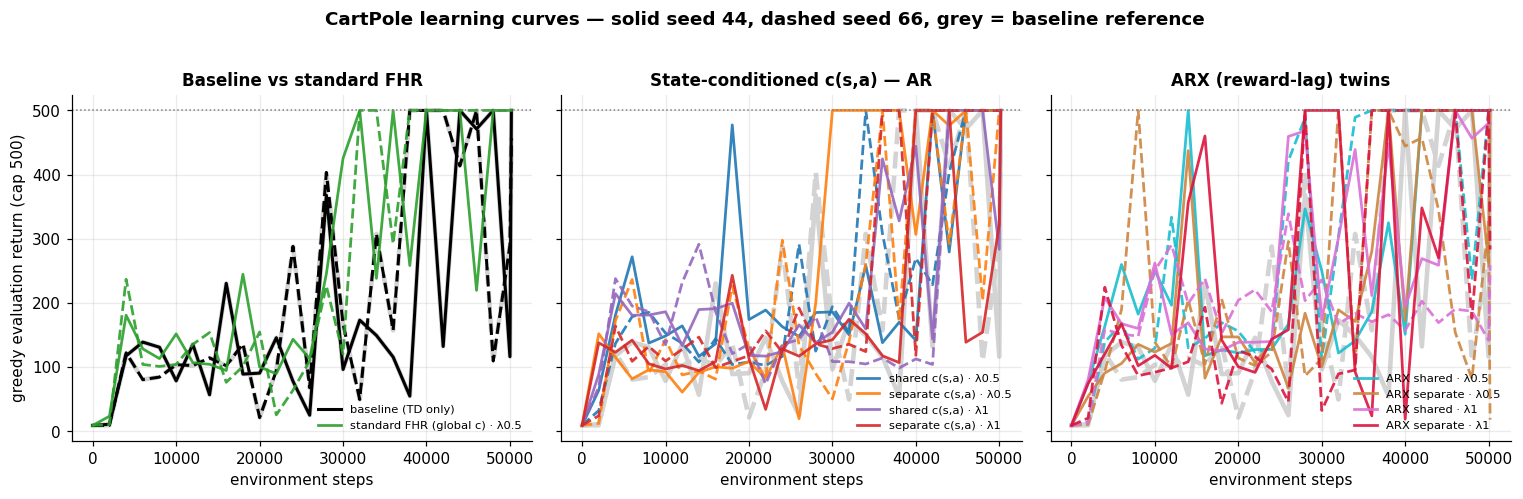

In [3]:
GROUPS = [
    ("Baseline vs standard FHR",
     ["baseline (TD only)", "standard FHR (global c) · λ0.5"]),
    ("State-conditioned c(s,a) — AR",
     ["shared c(s,a) · λ0.5", "separate c(s,a) · λ0.5",
      "shared c(s,a) · λ1", "separate c(s,a) · λ1"]),
    ("ARX (reward-lag) twins",
     ["ARX shared · λ0.5", "ARX separate · λ0.5",
      "ARX shared · λ1", "ARX separate · λ1"]),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (title, labels) in zip(axes, GROUPS):
    for seed, x, y in curves("baseline"):
        ax.plot(x, y, "-" if seed == "44" else "--", lw=3, color="lightgray",
                zorder=0)
    for label in labels:
        arm, col = ARMS[label]
        if arm == "baseline":
            for seed, x, y in curves(arm):
                ax.plot(x, y, "-" if seed == "44" else "--", lw=2,
                        color="black", label=label if seed == "44" else None)
            continue
        for seed, x, y in curves(arm):
            ax.plot(x, y, "-" if seed == "44" else "--", lw=1.8, color=col,
                    label=label if seed == "44" else None, alpha=0.9)
    ax.axhline(500, color="gray", ls=":", lw=1)
    ax.set(title=title, xlabel="environment steps")
    ax.legend(fontsize=7.5, loc="lower right")
axes[0].set_ylabel("greedy evaluation return (cap 500)")
fig.suptitle("CartPole learning curves — solid seed 44, dashed seed 66, "
             "grey = baseline reference", fontweight="bold", y=1.02)
plt.tight_layout()

## 2 · Final performance and the stability picture

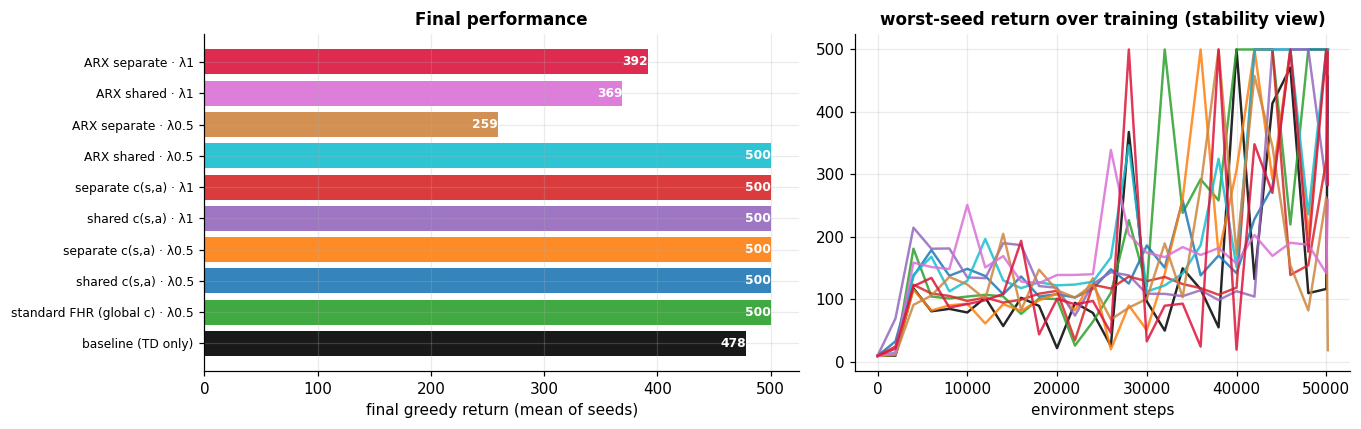

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4), width_ratios=[1.2, 1])
labels = list(ARMS)
means, mins = [], []
for label in labels:
    fs = [y[-1] for _, _, y in curves(ARMS[label][0])]
    means.append(np.mean(fs)); mins.append(min(fs))
a1.barh(range(len(labels)), means, color=[ARMS[l][1] for l in labels], alpha=0.9)
for y, m in enumerate(means):
    a1.annotate(f"{m:.0f}", (m, y), va="center", ha="right", fontsize=8,
                color="white", fontweight="bold")
a1.set_yticks(range(len(labels))); a1.set_yticklabels(labels, fontsize=8)
a1.set(xlabel="final greedy return (mean of seeds)", title="Final performance")
# stability: worst seed at every eval point
for label in labels:
    arm, col = ARMS[label]
    cs = curves(arm)
    if len(cs) == 2:
        x = cs[0][1]
        worst = np.minimum(cs[0][2], cs[1][2])
        a2.plot(x, worst, lw=1.6, color=col, alpha=0.85)
a2.set(title="worst-seed return over training (stability view)",
       xlabel="environment steps")
plt.tight_layout()

## 2b · Each variant vs the baseline and standard FHR

One panel per variant, three arms per panel: the **variant** (colour), the
**TD-only baseline** (grey) and **standard FHR** (black). Solid = seed 44,
dashed = seed 66.

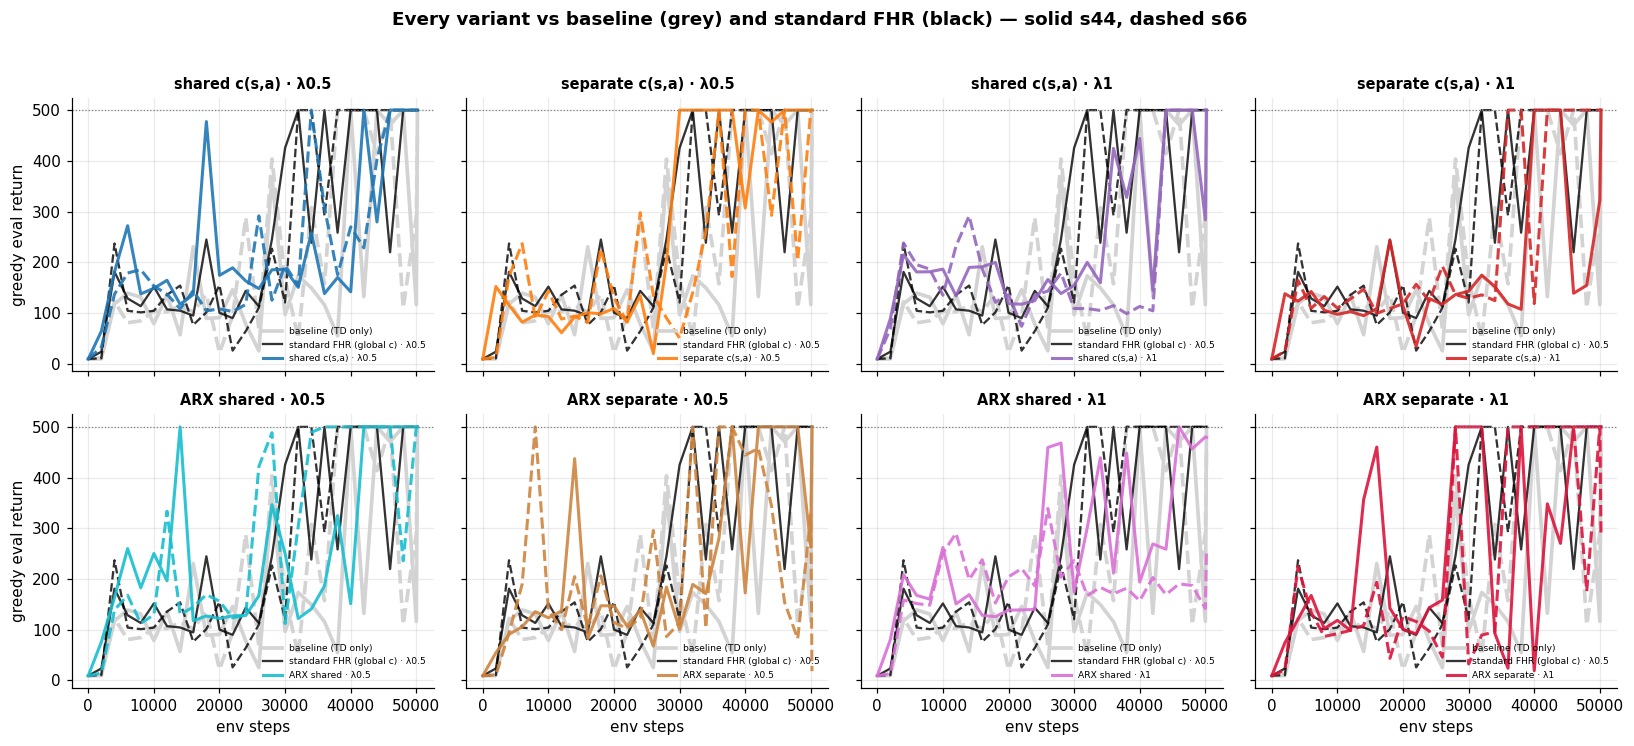

In [5]:
VARIANTS = [l for l in ARMS if "c(s,a)" in l or "ARX" in l]
REF_B = "baseline (TD only)"
REF_G = "standard FHR (global c) · λ0.5"

def plot_arm(ax, label, colr, lw, alpha=0.9):
    for seed, x, y in curves(ARMS[label][0]):
        ax.plot(x, y, "-" if seed == "44" else "--", lw=lw, color=colr,
                alpha=alpha, label=label if seed == "44" else None)

fig, axes = plt.subplots(2, 4, figsize=(15, 6.6), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), VARIANTS):
    plot_arm(ax, REF_B, "lightgray", 2.4, alpha=1.0)
    plot_arm(ax, REF_G, "black", 1.5, alpha=0.8)
    plot_arm(ax, label, ARMS[label][1], 2.0)
    ax.axhline(500, color="gray", ls=":", lw=0.8)
    ax.set_title(label, fontsize=9.5)
    ax.legend(fontsize=6, loc="lower right")
for ax in axes[1]: ax.set_xlabel("env steps")
for ax in axes[:, 0]: ax.set_ylabel("greedy eval return")
fig.suptitle("Every variant vs baseline (grey) and standard FHR (black) — "
             "solid s44, dashed s66", fontweight="bold", y=1.02)
plt.tight_layout()

## 2c · The recurrence loss — each variant vs standard FHR

Raw (unweighted) penalty over training, rolling-200, log scale: does the
state-conditioned c fit the sampled Q-transitions better than one global
vector, and does the fit advantage buy anything at the ceiling?

/tmp/ipykernel_984124/1070634556.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6)


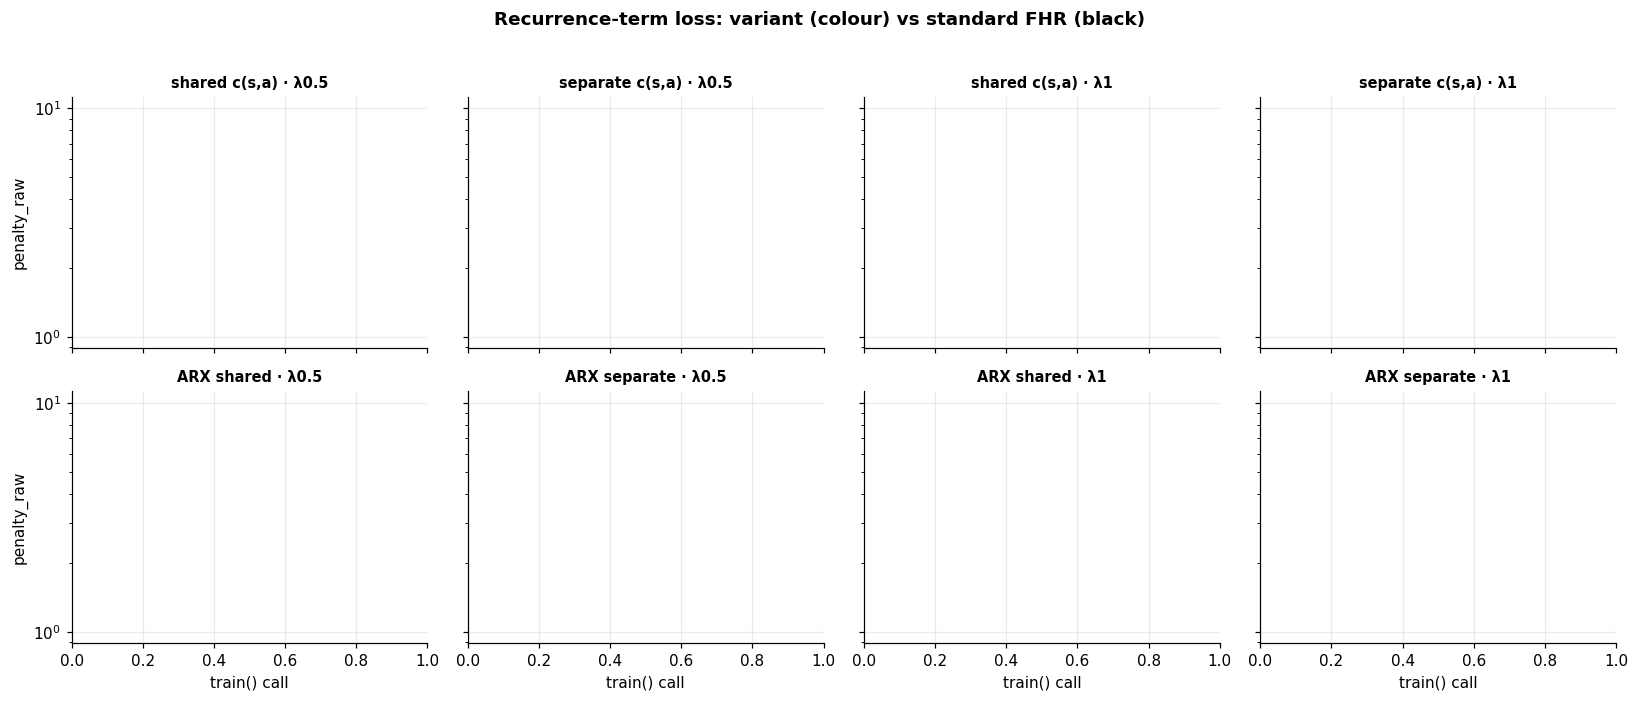

In [6]:
def plot_pen(ax, label, colr, lw):
    for seed in ("44", "66"):
        rel = CMAN["runs"].get(ARMS[label][0], {}).get(seed)
        if not rel: continue
        g = np.genfromtxt(str(pathlib.Path(rel) / "train_diagnostics.csv"),
                          delimiter=",", names=True)
        k = 200
        pen = np.nan_to_num(g["penalty_raw"])
        if len(pen) < k: continue
        sm = np.convolve(pen, np.ones(k) / k, "valid")
        ax.plot(sm, "-" if seed == "44" else "--", lw=lw, color=colr,
                label=label if seed == "44" else None)

fig, axes = plt.subplots(2, 4, figsize=(15, 6.2), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), VARIANTS):
    plot_pen(ax, REF_G, "black", 1.5)
    plot_pen(ax, label, ARMS[label][1], 1.9)
    ax.set_title(label, fontsize=9.5)
    ax.set_yscale("log")
    ax.legend(fontsize=6)
for ax in axes[1]: ax.set_xlabel("train() call")
for ax in axes[:, 0]: ax.set_ylabel("penalty_raw")
fig.suptitle("Recurrence-term loss: variant (colour) vs standard FHR (black)",
             fontweight="bold", y=1.02)
plt.tight_layout()

## 3 · Coefficient fields c(s, a) — pole-angle × angular-velocity slice

CartPole's state is 4-D; the informative slice fixes the cart at the centre
(x = ẋ = 0) and sweeps pole angle θ (±12° is the termination bound) against
angular velocity θ̇. Same reading as MountainCar: does the predictor learn
state structure, and where does it bend the recurrence?

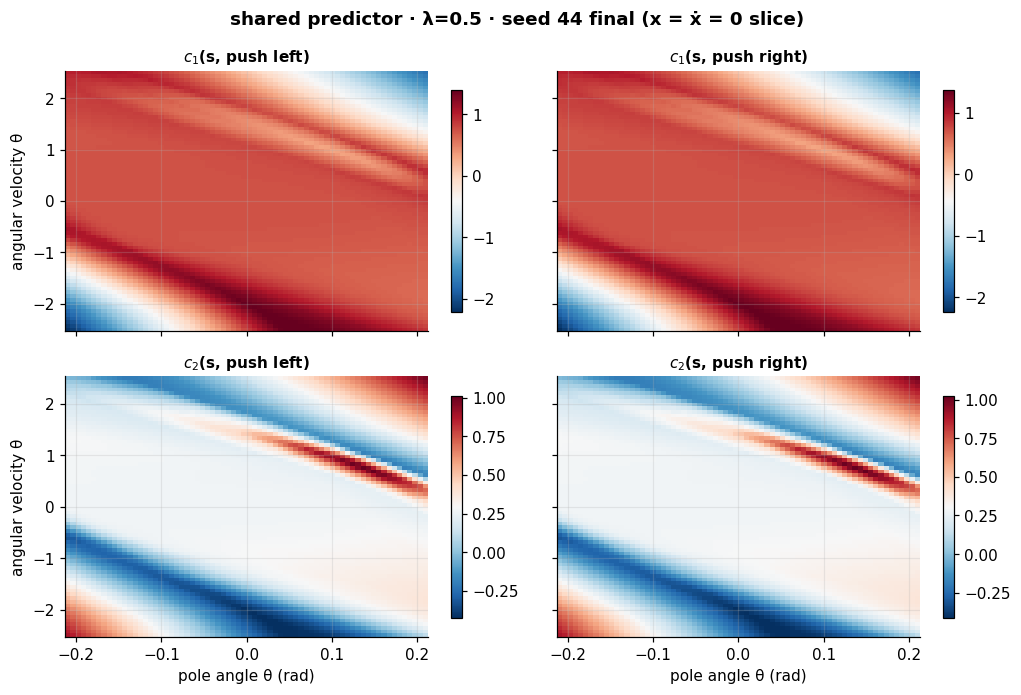

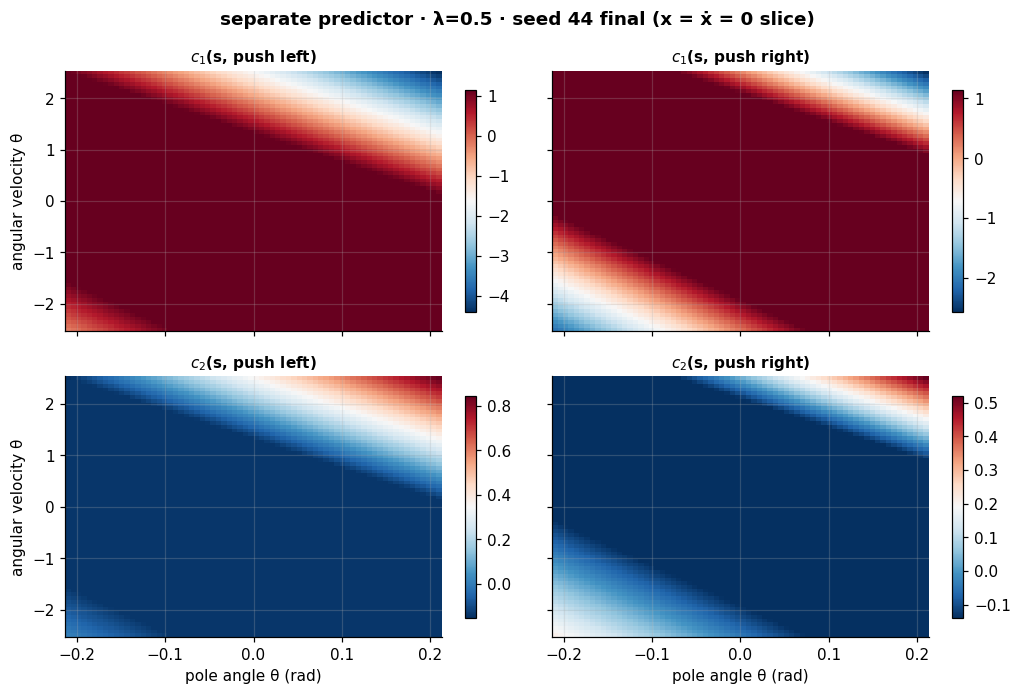

In [7]:
def load_model(arm, seed="44"):
    rel = CMAN["runs"][arm][seed]
    return FHRDQN.load(str(pathlib.Path(rel) / "checkpoints" / "final.pt"),
                       device="cpu")

TH, THD = np.meshgrid(np.linspace(-0.21, 0.21, 70), np.linspace(-2.5, 2.5, 70))
GRID = torch.tensor(np.stack([np.zeros(TH.size), np.zeros(TH.size),
                              TH.ravel(), THD.ravel()], 1), dtype=torch.float32)
for label, arm in (("shared", "exp1"), ("separate", "exp2")):
    model = load_model(arm)
    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), sharex=True, sharey=True)
    with torch.no_grad():
        for a_i, a_name in enumerate(("push left", "push right")):
            acts = torch.full((len(GRID),), a_i)
            feats = (penultimate_features(model.q_net, GRID)
                     if label == "shared" else GRID)
            c, _ = model.fhr_predictor(feats, acts)
            for lag in range(2):
                ax = axes[lag, a_i]
                im = ax.pcolormesh(TH, THD, c[:, lag].numpy().reshape(TH.shape),
                                   cmap="RdBu_r", shading="auto")
                fig.colorbar(im, ax=ax, shrink=0.85)
                ax.set_title(f"$c_{lag+1}$(s, {a_name})", fontsize=10)
    for ax in axes[1]: ax.set_xlabel("pole angle θ (rad)")
    for ax in axes[:, 0]: ax.set_ylabel("angular velocity θ̇")
    fig.suptitle(f"{label} predictor · λ=0.5 · seed 44 final (x = ẋ = 0 slice)",
                 fontweight="bold")
    plt.tight_layout()

## 4 · Value functions with and without the regulariser (same slice)

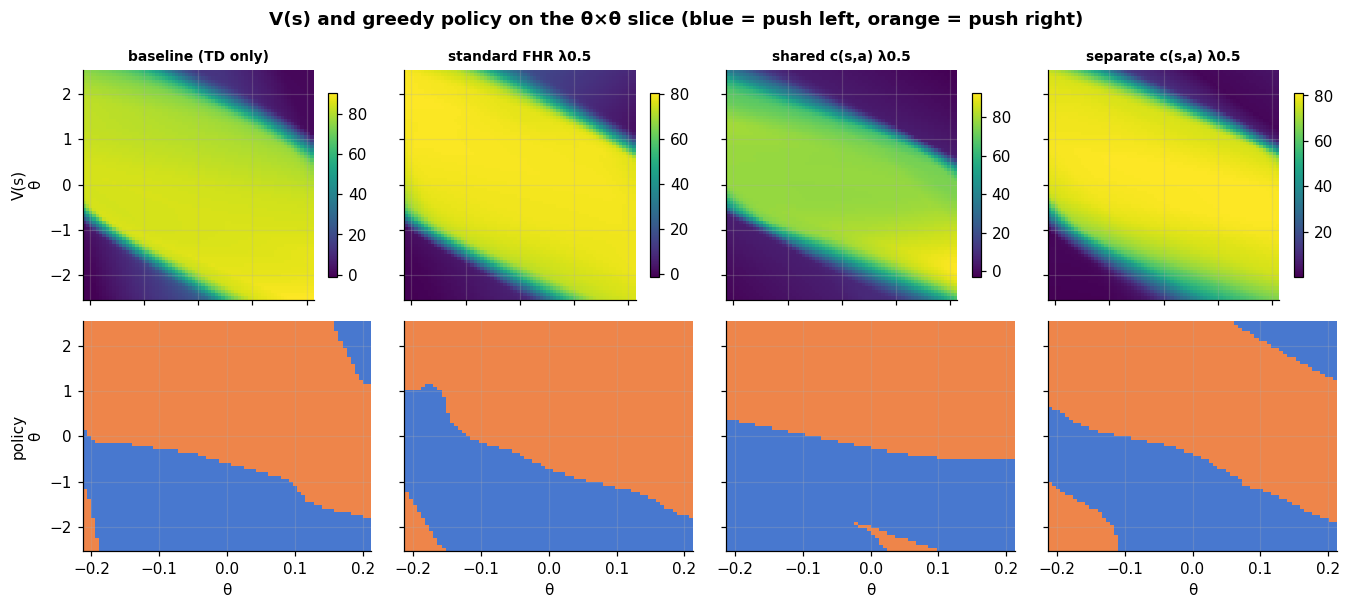

In [8]:
SHOW = [("baseline", "baseline (TD only)"), ("exp9", "standard FHR λ0.5"),
        ("exp1", "shared c(s,a) λ0.5"), ("exp2", "separate c(s,a) λ0.5")]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.1 * len(SHOW), 5.6),
                         sharex=True, sharey=True)
from matplotlib.colors import ListedColormap
pol_cmap = ListedColormap(["#4878CF", "#EE854A"])
for i, (arm, label) in enumerate(SHOW):
    model = load_model(arm)
    with torch.no_grad():
        q = model.q_net(GRID).numpy()
    im = axes[0, i].pcolormesh(TH, THD, q.max(1).reshape(TH.shape),
                               cmap="viridis", shading="auto")
    fig.colorbar(im, ax=axes[0, i], shrink=0.8)
    axes[0, i].set_title(label, fontsize=9)
    axes[1, i].pcolormesh(TH, THD, q.argmax(1).reshape(TH.shape),
                          cmap=pol_cmap, vmin=0, vmax=1, shading="auto")
    axes[1, i].set_xlabel("θ")
axes[0, 0].set_ylabel("V(s)\nθ̇"); axes[1, 0].set_ylabel("policy\nθ̇")
fig.suptitle("V(s) and greedy policy on the θ×θ̇ slice "
             "(blue = push left, orange = push right)", fontweight="bold")
plt.tight_layout()

## 5 · Hankel low-rankness of the value trajectory

One greedy episode per arm (both reach the 500-step cap): the Q-sequence with
its order-2 recurrence fit, the Hankel matrix as an image, and the singular
value cliff.

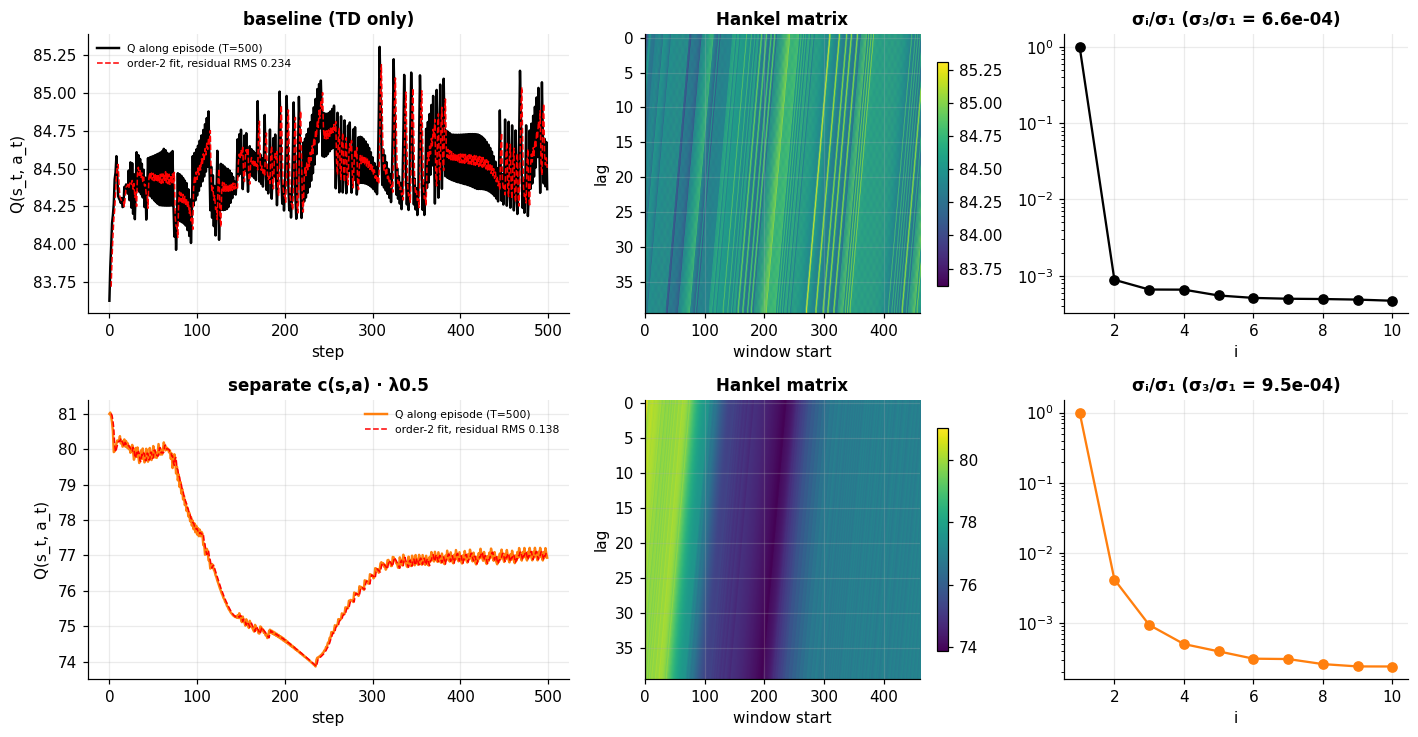

In [9]:
import gymnasium as gym

def greedy_traj_q(model, seed=7, max_steps=500):
    env = gym.make("CartPole-v1")
    obs, _ = env.reset(seed=seed)
    qs, done, trunc = [], False, False
    while not (done or trunc) and len(qs) < max_steps:
        with torch.no_grad():
            q = model.q_net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        a = int(q.argmax())
        qs.append(float(q[0, a]))
        obs, _, done, trunc, _ = env.step(a)
    env.close()
    return np.array(qs)

COMP = [("baseline (TD only)", "baseline", "black"),
        ("separate c(s,a) · λ0.5", "exp2", "tab:orange")]
fig, axes = plt.subplots(len(COMP), 3, figsize=(13, 3.4 * len(COMP)),
                         width_ratios=[1.4, 1, 1])
for row, (label, arm, col) in enumerate(COMP):
    q = greedy_traj_q(load_model(arm))
    T = len(q)
    X = np.stack([q[1:T-1], q[:T-2]], 1); y = q[2:]
    c = np.linalg.solve(X.T @ X + 1e-8 * np.eye(2), X.T @ y)
    pred = X @ c
    ax = axes[row, 0]
    ax.plot(q, lw=1.6, color=col, label=f"Q along episode (T={T})")
    ax.plot(range(2, T), pred, "--", lw=1, color="red",
            label=f"order-2 fit, residual RMS {np.sqrt(((q[2:]-pred)**2).mean()):.3f}")
    ax.set(title=label, xlabel="step", ylabel="Q(s_t, a_t)")
    ax.legend(fontsize=7)
    L = 40
    H = np.array([q[i:i + T - L + 1] for i in range(L)])
    im = axes[row, 1].imshow(H, aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8)
    axes[row, 1].set(title="Hankel matrix", xlabel="window start", ylabel="lag")
    s = np.linalg.svd(H, compute_uv=False)
    axes[row, 2].semilogy(range(1, 11), s[:10] / s[0], "o-", color=col)
    axes[row, 2].set(title=f"σᵢ/σ₁ (σ₃/σ₁ = {s[2]/s[0]:.1e})", xlabel="i")
plt.tight_layout()

## 6 · Findings

1. **Every AR-FHR variant solves CartPole on both seeds (500/500)** — global,
   shared, separate, at λ 0.5 and 1 alike — while the TD-only baseline ends
   seed 66 at 456.7 after a late-run wobble. At a hard score ceiling, FHR's
   contribution is **stabilisation**, and one λ=0.5 global penalty is already
   sufficient; state-conditioning neither helps nor hurts here.
2. **ARX destabilises a constant-reward environment**: with +1 every step
   there are no reward events for the d-lags to explain, so the extra slack
   only weakens the constraint — ARX-separate·λ0.5 reached 500 mid-run and
   collapsed to 18 (seed 66); both λ=1 ARX arms degrade. Third environment
   in a row (after Krull ↑ and MountainCar ↓) where ARX's effect tracks the
   presence of reward kinks exactly.
3. CartPole cannot rank the AR variants (all ceiling-locked) — it is the
   stability testcase in this trilogy; Acrobot (running) is the
   discriminative one.